In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


dish_data = pd.read_csv("data/Dish.csv", index_col="id")
dish_data.describe()

,description,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
count,0.0,426740.000000,426740.000000,426740.000000,426740.000000,397639.000000,397639.000000
mean,NaN,3.045430,3.126079,1662.388843,1666.144374,0.957152,1.590395
std,NaN,27.712989,29.854850,665.369340,666.038925,6.686869,12.643656
min,NaN,0.000000,-6.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,1.000000,1.000000,1900.000000,1900.000000,0.000000,0.000000
50%,NaN,1.000000,1.000000,1914.000000,1917.000000,0.000000,0.000000
75%,NaN,1.000000,1.000000,1949.000000,1955.000000,0.400000,0.550000
max,NaN,7747.000000,8495.000000,2928.000000,2928.000000,1035.000000,3050.000000


In [2]:
number_dish_data = dish_data.select_dtypes(include="number").drop(columns="description")
number_dish_data.head()

,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
id,,,,,,
1,8,8,1897,1927,0.20,0.4
2,111,117,1895,1960,0.10,0.8
3,14,14,1893,1917,0.25,0.4
4,41,41,1900,1971,0.25,1.0
5,66,68,1881,1981,0.00,18.0


In [3]:
number_dish_data.describe()

,menus_appeared,times_appeared,first_appeared,last_appeared,lowest_price,highest_price
count,426740.000000,426740.000000,426740.000000,426740.000000,397639.000000,397639.000000
mean,3.045430,3.126079,1662.388843,1666.144374,0.957152,1.590395
std,27.712989,29.854850,665.369340,666.038925,6.686869,12.643656
min,0.000000,-6.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,1900.000000,1900.000000,0.000000,0.000000
50%,1.000000,1.000000,1914.000000,1917.000000,0.000000,0.000000
75%,1.000000,1.000000,1949.000000,1955.000000,0.400000,0.550000
max,7747.000000,8495.000000,2928.000000,2928.000000,1035.000000,3050.000000


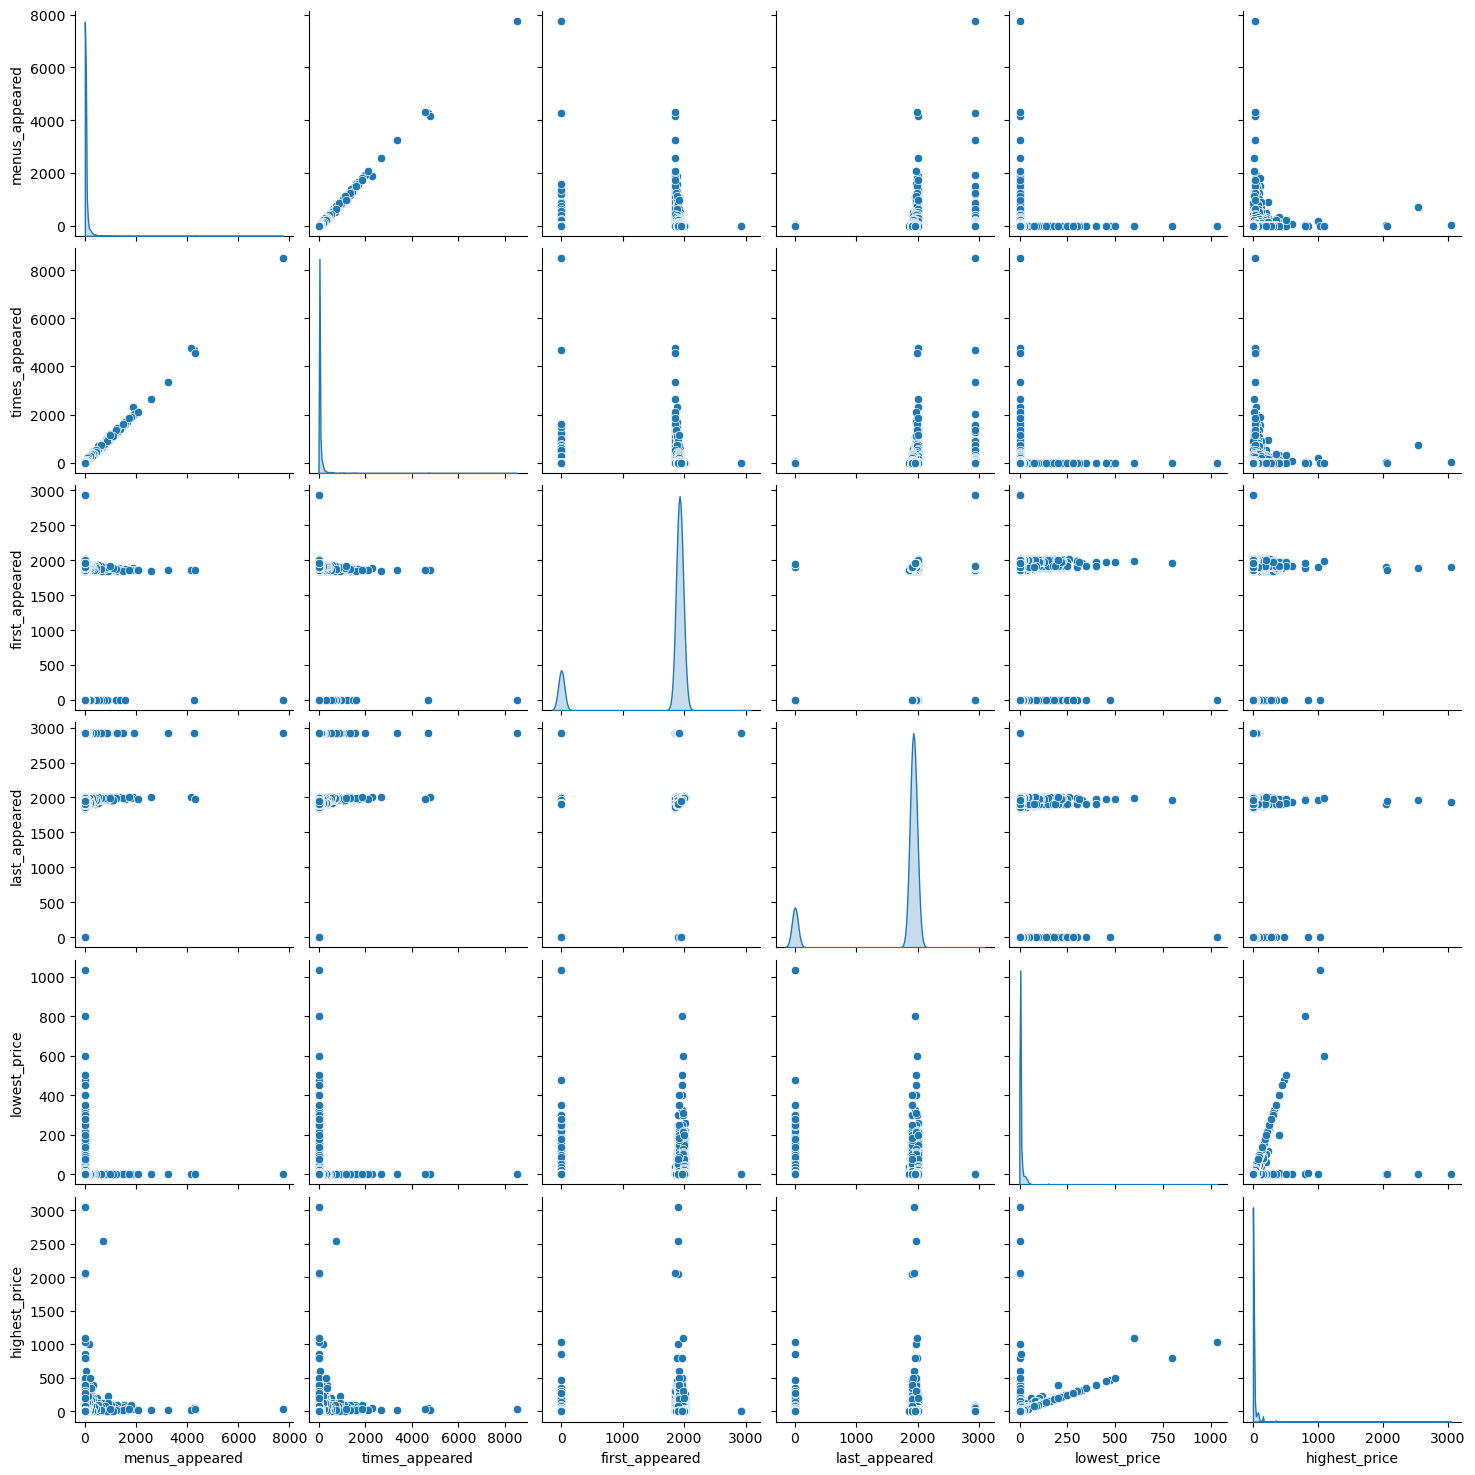

In [4]:
sns.pairplot(number_dish_data, diag_kind="kde")

Очистка

In [ ]:
features = number_dish_data.dropna(subset=["first_appeared", "last_appeared"])
features = features[(features["menus_appeared"] > 0) & (features["times_appeared"] > 0)]
features = features[(features["first_appeared"] <= 2026) & (features["last_appeared"] <= 2026)]

features = features[(features["lowest_price"].notna()) | (features["highest_price"].notna())]
features["highest_price"] = features["highest_price"].fillna(features["lowest_price"])
features["lowest_price"] = features["lowest_price"].fillna(features["highest_price"])

features["life_time"] = features["last_appeared"] - features["first_appeared"]
features["price_range"] = features["highest_price"] - features["lowest_price"]
features["avg_price"] = (features["highest_price"] + features["lowest_price"]) / 2


features = features[(features["life_time"] > 0) & (features["avg_price"] >= 0)]

features = features.loc[:, ["menus_appeared", "times_appeared", "life_time", "price_range", "avg_price"]]


In [21]:
features.describe()

,menus_appeared,times_appeared,life_time,price_range,avg_price
count,48982.000000,48982.000000,48982.000000,48982.000000,48982.000000
mean,15.584847,16.356805,27.677943,3.674183,2.236302
std,65.231879,70.099357,114.131608,28.745270,14.456219
min,1.000000,1.000000,1.000000,0.000000,0.000000
25%,2.000000,2.000000,3.000000,0.000000,0.000000
50%,4.000000,4.000000,11.000000,0.100000,0.325000
75%,9.000000,9.000000,32.000000,0.550000,0.850000
max,4323.000000,4778.000000,2012.000000,3049.550000,1525.225000


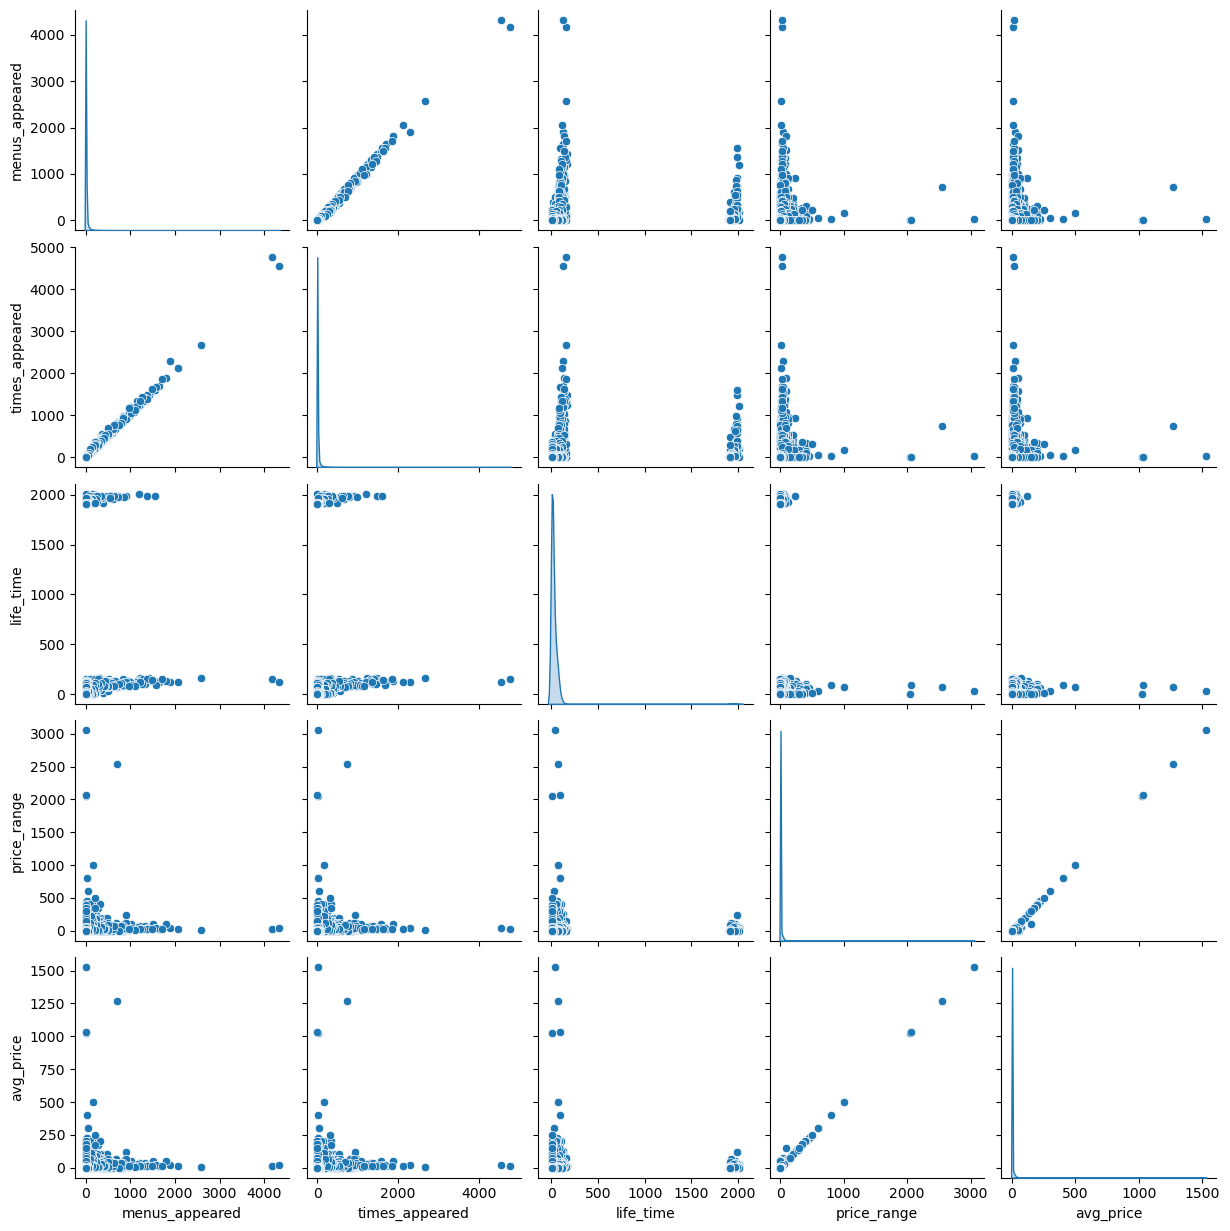

In [22]:
sns.pairplot(features, diag_kind="kde")

In [28]:
X = features.copy()

X = X.apply(lambda x: np.log1p(x))
X.describe()

,menus_appeared,times_appeared,life_time,price_range,avg_price
count,48982.000000,48982.000000,48982.000000,48982.000000,48982.000000
mean,1.936106,1.950663,2.461552,0.479669,0.539239
std,0.974071,0.988422,1.248155,0.934823,0.771566
min,0.693147,0.693147,0.693147,0.000000,0.000000
25%,1.098612,1.098612,1.386294,0.000000,0.000000
50%,1.609438,1.609438,2.484907,0.095310,0.281412
75%,2.302585,2.302585,3.496508,0.438255,0.615186
max,8.371936,8.471987,7.607381,8.023077,7.330553


In [29]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_std = StandardScaler().fit_transform(X)
X_mm = MinMaxScaler().fit_transform(X)